In [1200]:
# python libraries
import os
import sys 
# pyomo libraries
from pyomo.environ import (
    ConcreteModel,
    TransformationFactory,
    SolverFactory,
    Constraint,
    Var,
    Objective,
    minimize,
    value,
    units,
    check_optimal_termination,
)

sys.path.insert(1, os.path.join(sys.path[0], os.pardir, os.pardir))
current_dir = os.getcwd()
dir = os.path.dirname(os.path.dirname(os.path.dirname(current_dir)))
sys.path.append(dir) # Add the parent directory to Python's search path
from Opt_Layer.pyomolayer import PyomoOptLayer
import torch
import numpy as np
import matplotlib.pyplot as plt
# import IDAES core libraries
from idaes.core import FlowsheetBlock
from idaes.core.util.model_statistics import degrees_of_freedom
import idaes.core.util as iutil
import idaes.logger as idaeslog
import pyomo.environ as pyo
# import tsa unit model
from idaes.models_extra.temperature_swing_adsorption import (
    FixedBedTSA0D,
    FixedBedTSA0DInitializer,
    Adsorbent,
)
from idaes.models_extra.temperature_swing_adsorption.util import (
    tsa_summary,
    plot_tsa_profiles,
)

In [1201]:
# create concrete model
m = ConcreteModel()

# create flowsheet
m.fs = FlowsheetBlock(dynamic=False)
m.fs.tsa = FixedBedTSA0D(adsorbent=Adsorbent.zeolite_13x, number_of_beds=1)


In [1202]:
# fix inlet conditions of tsa unit - baseline case from Joss et al. 2015
# adjust the total 0.00960
total_flow_mol = 0.00960  # mol/s
# control total_flow_mol
# ourdoor temperature": 300.0,
#TODO Increase the pressure to 10 bar to help improve recovery
flue_gas = {
    "flow_mol_comp": {
        "H2O": 0.0,
        "CO2": total_flow_mol * 0.0004,
        "N2": total_flow_mol * 0.9996,
        "O2": 0.0,
    },
    "temperature": 300.0,
    "pressure": 1 * 1e5}
for i in m.fs.tsa.component_list:
    m.fs.tsa.inlet.flow_mol_comp[:, i].fix(flue_gas["flow_mol_comp"][i])
# outdoor temp, adsorbtioon temp.
m.fs.tsa.inlet.temperature.fix(flue_gas["temperature"])
m.fs.tsa.inlet.pressure.fix(flue_gas["pressure"])

In [1203]:
m.dummy_objective = Objective(expr=0, sense=minimize)

In [1204]:
# m.dummy_objective = Objective(expr= m.fs.tsa.purity + m.fs.tsa.recovery, sense=pyo.maximize)

In [1205]:
# fix design and operating variables of tsa unit - baseline case from Joss et al. 2015
# m.fs.tsa.temperature_desorption.fix(350)


# m.fs.tsa.adsorption.time.fix(6000)
# m.fs.tsa.heating.time.fix(200)

# m.fs.tsa.temperature_heating.fix(360)
#m.fs.tsa.temperature_cooling.fix(264)

m.fs.tsa.bed_diameter.fix(3 / 100)
m.fs.tsa.bed_height.fix(1.2)

In [1206]:
m.fs.tsa.temperature_desorption.fix(470)
m.fs.tsa.temperature_adsorption.fix(310)
m.fs.tsa.temperature_heating.fix(500)
m.fs.tsa.temperature_cooling.fix(300)

In [1193]:
def c_to_k(celsius):
    return celsius + 273.15


m.fs.tsa.temperature_adsorption.fix(c_to_k(40))
# m.fs.tsa.temperature_adsorption.setlb(274)
# m.fs.tsa.temperature_adsorption.setub(320)

m.fs.tsa.temperature_desorption.fix(c_to_k(210)) #120C
# m.fs.tsa.temperature_desorption.setlb(353)
# m.fs.tsa.temperature_desorption.setub(393)

## 10 greater than desorption
m.fs.tsa.temperature_heating.fix(c_to_k(210) + 10) 
# m.fs.tsa.temperature_heating.setlb(353)
# m.fs.tsa.temperature_heating.setub(413)

## 10 smaller than adsorption
m.fs.tsa.temperature_cooling.fix(c_to_k(40) - 10)

# m.fs.tsa.temperature_cooling.setlb(264)
# m.fs.tsa.temperature_cooling.setub(320)

m.fs.tsa.cooling.time.setlb(0)
m.fs.tsa.heating.time.setlb(0)
m.fs.tsa.adsorption.time.setlb(0)
m.fs.tsa.pressurization.time.setlb(0)

# m.fs.tsa.recovery.setlb(0)
# m.fs.tsa.purity.setlb(0)
# m.fs.tsa.recovery.setub(1)
# m.fs.tsa.purity.setub(1)

m.fs.tsa.pressure_adsorption.set_value(1 * 1e5)

In [1194]:
# @m.Constraint(m.fs.tsa.heating.time_domain, doc="Limit early outlet velocity")
# def limit_velocity_out(m, t):
#     if t <= 0.05:
#         return m.fs.tsa.heating.velocity_out[t] <= 0.04
#     return pyo.Constraint.Skip


In [1207]:
# check the degrees of freedom
DOF = degrees_of_freedom(m)
print(f"The DOF of the TSA unit is {DOF}")

The DOF of the TSA unit is 0


In [1208]:
# scaling factors
iutil.scaling.calculate_scaling_factors(m.fs.tsa)

In [1209]:

# define solver options
solver_options = {
    "tol": 1e-8,
}
# initialize tsa unit
initializer = FixedBedTSA0DInitializer(
    output_level=idaeslog.INFO, solver_options=solver_options
)

# How to control the time? Free some variables. 

In [1210]:
initializer.initialize(m.fs.tsa)

2025-07-02 20:13:44 [INFO] idaes.init.fs.tsa: Starting fixed bed TSA initialization
2025-07-02 20:13:45 [INFO] idaes.init.fs.tsa.heating: Starting initialization of heating step.
2025-07-02 20:13:45 [INFO] idaes.init.fs.tsa.heating: Initialization of heating step completed optimal - Optimal Solution Found.
2025-07-02 20:13:46 [INFO] idaes.init.fs.tsa.cooling: Starting initialization of cooling step.
2025-07-02 20:13:46 [INFO] idaes.init.fs.tsa.cooling: Initialization of cooling step completed optimal - Optimal Solution Found.
2025-07-02 20:13:46 [INFO] idaes.init.fs.tsa.pressurization: Starting initialization of pressurization step.
2025-07-02 20:13:46 [INFO] idaes.init.fs.tsa.pressurization: Initialization of pressurization step completed optimal - Optimal Solution Found.
2025-07-02 20:13:46 [INFO] idaes.init.fs.tsa.adsorption: Starting initialization of adsorption step.
2025-07-02 20:13:46 [INFO] idaes.init.fs.tsa.adsorption: Initialization of adsorption step completed optimal - Opti

In [1211]:
import pyomo.environ as pyo

m.dual = pyo.Suffix(direction=pyo.Suffix.IMPORT)
m.ipopt_zL_out = pyo.Suffix(direction=pyo.Suffix.IMPORT)
m.ipopt_zU_out = pyo.Suffix(direction=pyo.Suffix.IMPORT)

In [1212]:
m.display()

Model unknown

  Variables:
    None

  Objectives:
    dummy_objective : Size=1, Index=None, Active=True
        Key  : Active : Value
        None :   True :     0

  Constraints:
    None

  Blocks:
    Block fs
    
      Variables:
        None
    
      Objectives:
        None
    
      Constraints:
        None
    
      Blocks:
        Block fs.tsa
        
          Variables:
            flow_mol_in_total : Total mole flow rate at inlet
                Size=1, Index=None, Units=mol/s
                Key  : Lower : Value  : Upper : Fixed : Stale : Domain
                None :     0 : 0.0096 :  None : False : False : PositiveReals
            mole_frac_in : Mole fraction at inlet
                Size=2, Index=fs.tsa.isotherm_components, Units=dimensionless
                Key : Lower : Value  : Upper : Fixed : Stale : Domain
                CO2 :     0 : 0.0004 :  None : False : False : PositiveReals
                 N2 :     0 : 0.9996 :  None : False : False : PositiveRe

In [1213]:
print(m.fs.tsa.temperature_desorption.is_fixed())
print(m.fs.tsa.heating.time.is_fixed())

True
False


In [1214]:
# set up solver to solve flowsheet
solver = SolverFactory("ipopt")
solver.options = solver_options

# solve flowsheet
results = solver.solve(m, tee=True)

component keys that are not exported as part of the NL file.  Skipping.
Ipopt 3.13.2: tol=1e-08


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a colle

In [1215]:
# summary tsa
tsa_summary(m.fs.tsa)


Summary - tsa
------------------------------------------------------------------------------------                                                                  Value  
    Adsorption temperature [K]                                     310.00
    Desorption temperature [K]                                     470.00
    Heating temperature [K]                                        500.00
    Cooling temperature [K]                                        300.00
    Column diameter [m]                                          0.030000
    Column length [m]                                              1.2000
    Column volume [m3]                                         0.00084823
    CO2 mole fraction at feed [%]                                0.040000
    Feed flow rate [mol/s]                                      0.0096000
    Feed velocity [m/s]                                           0.50008
    Minimum fluidization velocity [m/s]                            1.5664
    Time of h

,Value
Adsorption temperature [K],310.000000
Desorption temperature [K],470.000000
Heating temperature [K],500.000000
Cooling temperature [K],300.000000
Column diameter [m],0.030000
Column length [m],1.200000
Column volume [m3],0.000848
CO2 mole fraction at feed [%],0.040000
Feed flow rate [mol/s],0.009600
Feed velocity [m/s],0.500077


In [619]:
m.display()

Model unknown

  Variables:
    None

  Objectives:
    dummy_objective : Size=1, Index=None, Active=True
        Key  : Active : Value
        None :   True :     0

  Constraints:
    None

  Blocks:
    Block fs
    
      Variables:
        None
    
      Objectives:
        None
    
      Constraints:
        None
    
      Blocks:
        Block fs.tsa
        
          Variables:
            flow_mol_in_total : Total mole flow rate at inlet
                Size=1, Index=None, Units=mol/s
                Key  : Lower : Value  : Upper : Fixed : Stale : Domain
                None :     0 : 0.0096 :  None : False : False : PositiveReals
            mole_frac_in : Mole fraction at inlet
                Size=2, Index=fs.tsa.isotherm_components, Units=dimensionless
                Key : Lower : Value              : Upper : Fixed : Stale : Domain
                CO2 :     0 :              0.004 :  None : False : False : PositiveReals
                 N2 :     0 : 0.9960000000000001 

In [53]:
# parameters_name = [m.fs.tsa.temperature_desorption, m.fs.tsa.temperature_heating]
parameters_name = [m.fs.tsa.temperature_adsorption, m.fs.tsa.temperature_cooling]
# parameters_name =[m.fs.tsa.bed_diameter, m.fs.tsa.bed_height]
variables_name = [m.fs.tsa.productivity, m.fs.tsa.specific_energy]
slacks_name = None
known_parameters_name = None
free_parameters_name = None
Layer = PyomoOptLayer(m, variables_name, parameters_name, free_parameters_name, known_parameters_name, slacks_name, ipopt_options = solver_options)

component keys that are not exported as part of the NL file.  Skipping.
component keys that are not exported as part of the NL file.  Skipping.


In [49]:
# nominoal_adsorption = [270.0]
# nominoal_desorption = [350.0]

# nominoal_adsorption  = torch.tensor(np.array(nominoal_adsorption).reshape(1, -1), requires_grad=True)
# nominoal_desorption  = torch.tensor(np.array(nominoal_desorption).reshape(1, -1), requires_grad=True)
# nominoal_adsorption.shape

torch.Size([1, 1])

In [54]:
nominoal_adsorption = []
nominoal_temperature_cooling = []
for celsius in range(0, 40, 1):
    kelvin = celsius + 273.15
    nominoal_adsorption.append(kelvin)
    nominoal_temperature_cooling.append(kelvin - 10)
nominoal_adsorption = torch.tensor(np.array(nominoal_adsorption).reshape(-1, 1), requires_grad=True)
nominoal_temperature_cooling = torch.tensor(np.array(nominoal_temperature_cooling).reshape(-1, 1), requires_grad=True)
print(nominoal_adsorption )
nominoal_adsorption.shape

tensor([[273.1500],
        [274.1500],
        [275.1500],
        [276.1500],
        [277.1500],
        [278.1500],
        [279.1500],
        [280.1500],
        [281.1500],
        [282.1500],
        [283.1500],
        [284.1500],
        [285.1500],
        [286.1500],
        [287.1500],
        [288.1500],
        [289.1500],
        [290.1500],
        [291.1500],
        [292.1500],
        [293.1500],
        [294.1500],
        [295.1500],
        [296.1500],
        [297.1500],
        [298.1500],
        [299.1500],
        [300.1500],
        [301.1500],
        [302.1500],
        [303.1500],
        [304.1500],
        [305.1500],
        [306.1500],
        [307.1500],
        [308.1500],
        [309.1500],
        [310.1500],
        [311.1500],
        [312.1500]], requires_grad=True)


torch.Size([40, 1])

In [55]:
input = tuple([nominoal_adsorption, nominoal_temperature_cooling])

primal_batch, slack_out, dual_out,  lhs, rhs, J = Layer(*input)

component keys that are not exported as part of the NL file.  Skipping.
component keys that are not exported as part of the NL file.  Skipping.
component keys that are not exported as part of the NL file.  Skipping.
component keys that are not exported as part of the NL file.  Skipping.
component keys that are not exported as part of the NL file.  Skipping.
component keys that are not exported as part of the NL file.  Skipping.
component keys that are not exported as part of the NL file.  Skipping.
component keys that are not exported as part of the NL file.  Skipping.
component keys that are not exported as part of the NL file.  Skipping.
component keys that are not exported as part of the NL file.  Skipping.
component keys that are not exported as part of the NL file.  Skipping.
component keys that are not exported as part of the NL file.  Skipping.
component keys that are not exported as part of the NL file.  Skipping.
component keys that are not exported as part of the NL file.  Sk

In [155]:
nominoal_desorption = []
nominoal_temperature_heating = []
for celsius in range(80, 120, 1):
    kelvin = celsius + 273.15
    nominoal_desorption.append(kelvin)
    nominoal_temperature_heating.append(kelvin + 10)
nominoal_desorption = torch.tensor(np.array(nominoal_desorption).reshape(-1, 1), requires_grad=True)
nominoal_temperature_heating = torch.tensor(np.array(nominoal_temperature_heating).reshape(-1, 1), requires_grad=True)
print(nominoal_desorption)
nominoal_desorption.shape

tensor([[353.1500],
        [354.1500],
        [355.1500],
        [356.1500],
        [357.1500],
        [358.1500],
        [359.1500],
        [360.1500],
        [361.1500],
        [362.1500],
        [363.1500],
        [364.1500],
        [365.1500],
        [366.1500],
        [367.1500],
        [368.1500],
        [369.1500],
        [370.1500],
        [371.1500],
        [372.1500],
        [373.1500],
        [374.1500],
        [375.1500],
        [376.1500],
        [377.1500],
        [378.1500],
        [379.1500],
        [380.1500],
        [381.1500],
        [382.1500],
        [383.1500],
        [384.1500],
        [385.1500],
        [386.1500],
        [387.1500],
        [388.1500],
        [389.1500],
        [390.1500],
        [391.1500],
        [392.1500]], requires_grad=True)


torch.Size([40, 1])

In [156]:
input = tuple([nominoal_desorption, nominoal_temperature_heating])

primal_batch, slack_out, dual_out,  lhs, rhs, J = Layer(*input)

component keys that are not exported as part of the NL file.  Skipping.
IPOPT failed to converge! Please consider the slack model
component keys that are not exported as part of the NL file.  Skipping.


KeyboardInterrupt: 

In [ ]:
nominoal_bed_diameter = []
nominoal_bed_height = []
for celsius in range(1, 10, 1):
    nominoal_bed_diameter.append(celsius / 100)
    nominoal_bed_height.append(kelvin + 10)
nominoal_desorption = torch.tensor(np.array(nominoal_desorption).reshape(-1, 1), requires_grad=True)
nominoal_temperature_heating = torch.tensor(np.array(nominoal_temperature_heating).reshape(-1, 1), requires_grad=True)
print(nominoal_desorption)
nominoal_desorption.shape

Text(0.5, 1.0, 'When adsorption temperature is fixed at 0C')

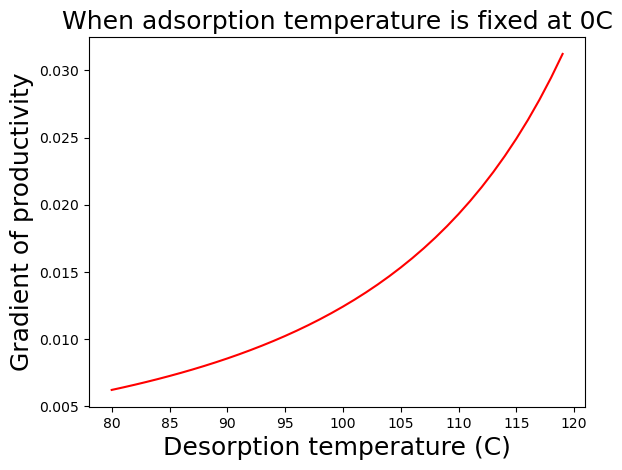

In [112]:
plt.plot(nominoal_desorption.detach().numpy() - 273.15 , J.detach().numpy()[:, 0, 0], color='red')
plt.xlabel("Desorption temperature (C)", fontsize=18)
plt.ylabel("Gradient of productivity", fontsize=18)
plt.title("When adsorption temperature is fixed at 0C", fontsize=18)

Text(0.5, 1.0, 'When adsorption temperature is fixed at 0C')

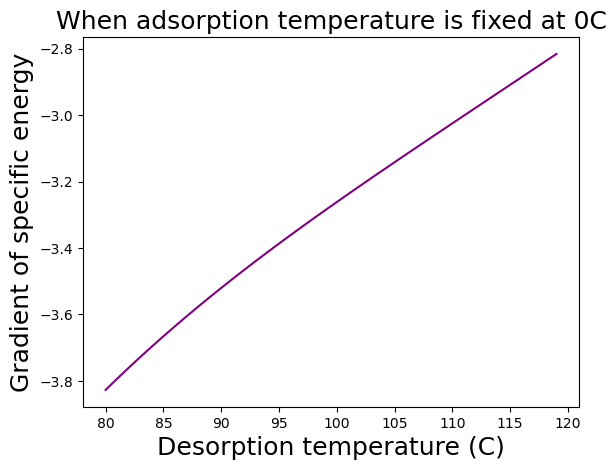

In [114]:
plt.plot(nominoal_desorption.detach().numpy() - 273.15, J.detach().numpy()[:, 1, 0], color='purple')
plt.xlabel("Desorption temperature (C)", fontsize=18)
plt.ylabel("Gradient of specific energy", fontsize=18)
plt.title("When adsorption temperature is fixed at 0C", fontsize=18)

Text(0.5, 1.0, 'When adsorption temperature is fixed at 80C')

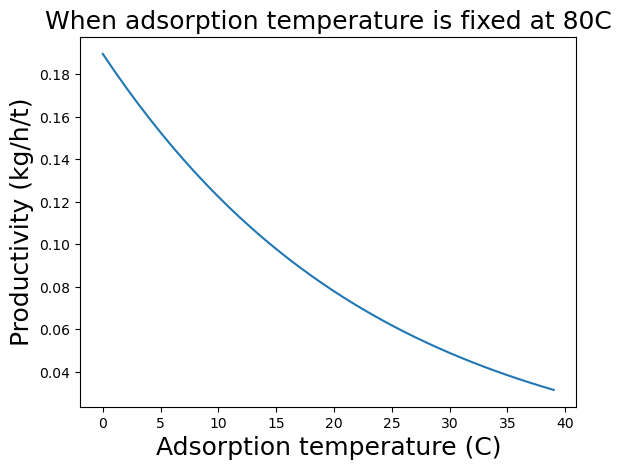

In [96]:
plt.plot(nominoal_adsorption.detach().numpy() - 273.15, primal_batch.detach().numpy()[:, 0])
plt.xlabel("Adsorption temperature (C)", fontsize=18)
plt.ylabel("Productivity (kg/h/t)", fontsize=18)
plt.title("When adsorption temperature is fixed at 80C", fontsize=18)

Text(0.5, 1.0, 'When desorption temperature is fixed at 80C')

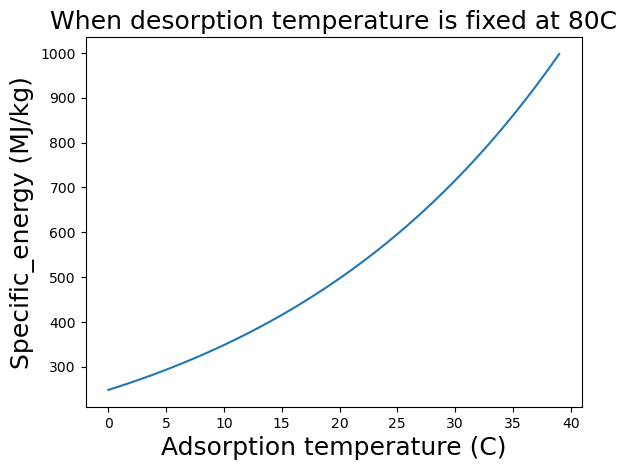

In [97]:
plt.plot(nominoal_adsorption.detach().numpy() - 273.15, primal_batch.detach().numpy()[:, 1])
plt.xlabel("Adsorption temperature (C)", fontsize=18)
plt.ylabel("Specific_energy (MJ/kg)", fontsize=18)
plt.title("When desorption temperature is fixed at 80C", fontsize=18)

In [20]:
print("productivity", primal_batch[0][0])
print("energy", primal_batch[0][1])

productivity tensor(0.4533, grad_fn=<SelectBackward0>)
energy tensor(193.7170, grad_fn=<SelectBackward0>)


In [19]:
print("grad", J)
print("productivity", primal_batch[0][0])
print("energy", primal_batch[0][1])

grad tensor([[[ 0.0144],
         [-5.4253]]], grad_fn=<PyomoLayerFnFnBackward>)
productivity tensor(0.4533, grad_fn=<SelectBackward0>)
energy tensor(193.7170, grad_fn=<SelectBackward0>)


In [ ]:
increase temp -> drease productivity
increase temp -> increase specific energy

Try this range to find the optimal setup.
ab 240 - 400 K 
de 350 - 500 K 
range of the temperature -> abmbient temperature

resolution: continuous
Goal: minimize specific energy (Specific thermal energy consumption, Units=MJ/kg) + maximaze productivity Units=kg/h/t

In [ ]:
feed_velocity (velocity_mf) -  range?

In [ ]:
temperature_desorption -> specific_energy

In [ ]:
show the sensitivity analysis -> compared with the first order result

In [ ]:
# x -> y = f(x)
x + 1 -> y1
x - 1 -> y2
(y1 - y2) / 2

# 1% increase in x

In [ ]:
Next step:

